In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
N_SPLITS = 5

## Wczytanie danych

In [4]:
df_train = pd.read_csv('..//data/train.csv')
df_test = pd.read_csv('..//data/test.csv')

test_ids = df_test['id'].copy()


## Preprocessing

Stosujemy minimalne kodowanie - mapping ordinalny dla grade_subgrade i education_level, natywny dtype category dla pozostalych cech kategorycznych.

Uzasadnienie (zwalidowane w notebooku EDA): modele gradient boosting same obsluguja interakcje miedzy cechami i podzialy kategoryczne. Reczny feature engineering (np. loan_to_income, dti_squared) nie poprawil wynikow w 5-fold CV.

In [3]:
def prepare_data(df):
    """
    Minimalna transformacja danych.
    
    - education_level -> education_rank (ordinal: Other=1, ..., PhD=5)
    - grade_subgrade  -> grade_rank (A=0,...,F=5) + subgrade_num (czesc numeryczna)
    - Pozostale kategoryczne -> dtype 'category' (natywna obsluga przez LightGBM/XGBoost/CatBoost)
    - Usuwamy: id, education_level, grade_subgrade (zastapione nowymi kolumnami)
    
    Zwraca DataFrame z 12 cechami.
    """
    df = df.copy()
    
    education_ranking = {"PhD": 5, "Master's": 4, "Bachelor's": 3, "High School": 2, "Other": 1}
    df['education_rank'] = df['education_level'].map(education_ranking)
    
    df['subgrade_num'] = df['grade_subgrade'].str[1:].astype(float)
    grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
    df['grade_rank'] = df['grade_subgrade'].str[0].map(grade_map)
    
    cat_columns = ['gender', 'marital_status', 'employment_status', 'loan_purpose']
    for col in cat_columns:
        df[col] = df[col].astype('category')
    
    cols_to_drop = ['id', 'education_level', 'grade_subgrade']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    return df

df_processed = prepare_data(df_train)

X = df_processed.drop(columns=['loan_paid_back'])
y = df_processed['loan_paid_back']

X_test = prepare_data(df_test)
X_test = X_test[X.columns]

print(f"Cechy ({X.shape[1]}): {list(X.columns)}")
print(f"Train: {len(X)} probek, Test: {len(X_test)} probek")

Cechy (12): ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'gender', 'marital_status', 'employment_status', 'loan_purpose', 'education_rank', 'subgrade_num', 'grade_rank']
Train: 593994 probek, Test: 254569 probek


## Wczytanie hiperparametrów z hiperparams_finding.ipynb.

Wszystkie hiperparametry zostaly ztunowane przy uzyciu Optuna. Pelny kod tuningu w hiperparams_finding.ipynb.

In [ ]:
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'n_estimators': 883,
    'learning_rate': 0.07215875540586067,
    'max_depth': 8,
    'num_leaves': 79,
    'min_child_samples': 439,
    'reg_alpha': 0.12230989377439495,
    'reg_lambda': 0.01652433952477553,
    'subsample': 0.6879714949174074,
    'colsample_bytree': 0.40851406786087663,
}

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'enable_categorical': True,
    'tree_method': 'hist',
    'n_estimators': 1099,
    'learning_rate': 0.05988334845001533,
    'max_depth': 6,
    'min_child_weight': 89,
    'gamma': 0.001636755574517893,
    'reg_alpha': 0.07616682593289427,
    'reg_lambda': 0.02219254203900335,
    'subsample': 0.9204389358382835,
    'colsample_bytree': 0.4535710403607285,
}

cat_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': RANDOM_STATE,
    'thread_count': -1,
    'verbose': False,
    'bootstrap_type': 'Bayesian',
    'iterations': 1176,
    'learning_rate': 0.0411659297782639,
    'depth': 8,
    'l2_leaf_reg': 18.976642177265127,
    'random_strength': 0.0016250354947837794,
    'bagging_temperature': 0.36215545821644324,
    'border_count': 190,
}

cat_features_list = ['gender', 'marital_status', 'employment_status', 'loan_purpose']

## Trening OOF - wszystkie modele

Generujemy predykcje out-of-fold dla wszystkich 5 modeli w jednej petli 5-fold CV. Kazdy model generuje predykcje na walidacji (OOF) i na zbiorze testowym (usrednione po foldach).

Regresja logistyczna i Random Forest wymagaja danych numerycznych, wiec robimy dla nich osobny one-hot encoding. Modele GBM dzialaja na natywnych kategoriach.

In [ ]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cat_cols_for_encoding = ['gender', 'marital_status', 'employment_status', 'loan_purpose']
X_num = pd.get_dummies(X, columns=cat_cols_for_encoding, drop_first=True).astype(float)
X_test_num = pd.get_dummies(X_test, columns=cat_cols_for_encoding, drop_first=True).astype(float)
X_test_num = X_test_num.reindex(columns=X_num.columns, fill_value=0)
cat_features_list = ['gender', 'marital_status', 'employment_status', 'loan_purpose']
oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_logit = np.zeros(len(X))
oof_rf = np.zeros(len(X))
test_lgb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))
test_cat = np.zeros(len(X_test))
test_logit = np.zeros(len(X_test_num))
test_rf = np.zeros(len(X_test_num))
print(f"Rozpoczynam {N_SPLITS}-fold trening dla 5 modeli...\n")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"--- FOLD {fold+1}/{N_SPLITS} ---")
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
    
    # Wersje numeryczne dla tego folda
    X_train_num = X_num.iloc[train_idx]
    X_val_num = X_num.iloc[val_idx]
    
    # LightGBM
    print("  LightGBM...")
    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    oof_lgb[val_idx] = model_lgb.predict_proba(X_val_fold)[:, 1]
    test_lgb += model_lgb.predict_proba(X_test)[:, 1] / N_SPLITS
    
    # XGBoost
    print("  XGBoost...")
    model_xgb = xgb.XGBClassifier(**xgb_params, early_stopping_rounds=50)
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_val_fold, y_val_fold)],
        verbose=False
    )
    oof_xgb[val_idx] = model_xgb.predict_proba(X_val_fold)[:, 1]
    test_xgb += model_xgb.predict_proba(X_test)[:, 1] / N_SPLITS
    
    # CatBoost
    print("  CatBoost...")
    model_cat = CatBoostClassifier(**cat_params, cat_features=cat_features_list)
    model_cat.fit(
        X_train, y_train,
        eval_set=(X_val_fold, y_val_fold),
        early_stopping_rounds=50
    )
    oof_cat[val_idx] = model_cat.predict_proba(X_val_fold)[:, 1]
    test_cat += model_cat.predict_proba(X_test)[:, 1] / N_SPLITS
    
    # Regresja logistyczna (na danych numerycznych)
    print("  Logistic Regression...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_num)
    X_val_scaled = scaler.transform(X_val_num)
    X_test_scaled = scaler.transform(X_test_num)
    
    model_logit = LogisticRegression(max_iter=200, class_weight='balanced', random_state=RANDOM_STATE)
    model_logit.fit(X_train_scaled, y_train)
    oof_logit[val_idx] = model_logit.predict_proba(X_val_scaled)[:, 1]
    test_logit += model_logit.predict_proba(X_test_scaled)[:, 1] / N_SPLITS
    
    # Random Forest (na danych numerycznych)
    print("  Random Forest...")
    model_rf = RandomForestClassifier(
        n_estimators=400, class_weight={0:4, 1:1}, random_state=RANDOM_STATE, n_jobs=-1
    )
    model_rf.fit(X_train_num, y_train)
    oof_rf[val_idx] = model_rf.predict_proba(X_val_num)[:, 1]
    test_rf += model_rf.predict_proba(X_test_num)[:, 1] / N_SPLITS
print("\n=== TRENING ZAKONCZONY ===")
print(f"OOF AUC - LightGBM:            {roc_auc_score(y, oof_lgb):.5f}")
print(f"OOF AUC - XGBoost:             {roc_auc_score(y, oof_xgb):.5f}")
print(f"OOF AUC - CatBoost:            {roc_auc_score(y, oof_cat):.5f}")
print(f"OOF AUC - Logistic Regression: {roc_auc_score(y, oof_logit):.5f}")
print(f"OOF AUC - Random Forest:       {roc_auc_score(y, oof_rf):.5f}")

Rozpoczynam 5-fold trening dla 5 modeli...

--- FOLD 1/5 ---
  LightGBM...
  XGBoost...
  CatBoost...
  Logistic Regression...
  Random Forest...
--- FOLD 2/5 ---
  LightGBM...
  XGBoost...
  CatBoost...
  Logistic Regression...
  Random Forest...
--- FOLD 3/5 ---
  LightGBM...
  XGBoost...
  CatBoost...
  Logistic Regression...
  Random Forest...
--- FOLD 4/5 ---
  LightGBM...
  XGBoost...
  CatBoost...
  Logistic Regression...
  Random Forest...
--- FOLD 5/5 ---
  LightGBM...
  XGBoost...
  CatBoost...
  Logistic Regression...
  Random Forest...

=== TRENING ZAKONCZONY ===
OOF AUC - LightGBM:            0.92354
OOF AUC - XGBoost:             0.92221
OOF AUC - CatBoost:            0.92051
OOF AUC - Logistic Regression: 0.91023
OOF AUC - Random Forest:       0.91084


## Korelacja predykcji miedzy modelami

Zanim przejdziemy do stackingu, warto sprawdzic jak bardzo skorelowane sa predykcje poszczegolnych modeli. Im mniejsza korelacja, tym wiekszy potencjalny zysk z ensemblowania.

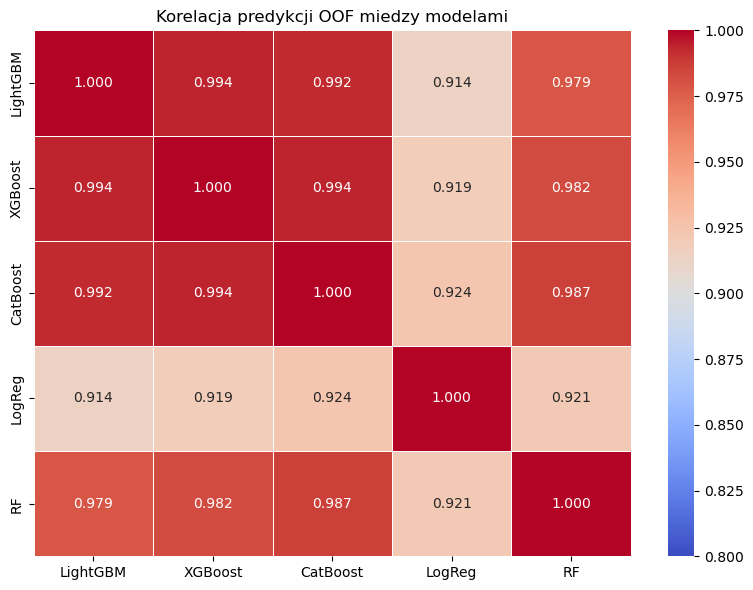

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df_preds = pd.DataFrame({
    'LightGBM': oof_lgb,
    'XGBoost': oof_xgb,
    'CatBoost': oof_cat,
    'LogReg': oof_logit,
    'RF': oof_rf
})

corr = df_preds.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5, vmin=0.8, vmax=1.0)
plt.title('Korelacja predykcji OOF miedzy modelami')
plt.tight_layout()
plt.show()

Wszystkie testowane modele wykazują bardzo silną dodatnią korelację między swoimi predykcjami – najniższa zanotowana wartość to 0.914. Niska wartość dodana z łączenia samych modeli boostingowych. Kluczowa rola Regresji Logistycznej

## Stacking - porownanie wariantow

### Wariant A: 3 modele GBM

In [7]:
# Stacking 3 modeli (LightGBM + XGBoost + CatBoost)
meta_3 = pd.DataFrame({
    'LightGBM': oof_lgb,
    'XGBoost': oof_xgb,
    'CatBoost': oof_cat
})

meta_model_3 = LogisticRegression(random_state=RANDOM_STATE)
meta_model_3.fit(meta_3, y)

stacking_3_preds = meta_model_3.predict_proba(meta_3)[:, 1]
auc_3 = roc_auc_score(y, stacking_3_preds)

print(f"Stacking 3 modeli - OOF AUC: {auc_3:.5f}")
print("Wagi:")
for name, coef in zip(meta_3.columns, meta_model_3.coef_[0]):
    print(f"  {name:12s}: {coef:.3f}")

Stacking 3 modeli - OOF AUC: 0.92355
Wagi:
  LightGBM    : 4.945
  XGBoost     : 1.716
  CatBoost    : 0.379


### Wariant B: 5 modeli (GBM + LogReg + RF)

In [8]:
# Stacking 5 modeli
meta_5 = pd.DataFrame({
    'LightGBM': oof_lgb,
    'XGBoost': oof_xgb,
    'CatBoost': oof_cat,
    'LogReg': oof_logit,
    'RF': oof_rf
})

meta_model_5 = LogisticRegression(random_state=RANDOM_STATE)
meta_model_5.fit(meta_5, y)

stacking_5_preds = meta_model_5.predict_proba(meta_5)[:, 1]
auc_5 = roc_auc_score(y, stacking_5_preds)

print(f"Stacking 5 modeli - OOF AUC: {auc_5:.5f}")
print("Wagi:")
for name, coef in zip(meta_5.columns, meta_model_5.coef_[0]):
    print(f"  {name:12s}: {coef:.3f}")

Stacking 5 modeli - OOF AUC: 0.92251
Wagi:
  LightGBM    : 5.029
  XGBoost     : 1.423
  CatBoost    : -0.210
  LogReg      : 1.184
  RF          : -0.497


### Wariant C: bez CatBoost (LightGBM + XGBoost + LogReg)

In [14]:
meta_c = pd.DataFrame({
    'LightGBM': oof_lgb,
    'XGBoost': oof_xgb,
    'LogReg': oof_logit
})

meta_model_c = LogisticRegression(random_state=RANDOM_STATE)
meta_model_c.fit(meta_c, y)

stacking_c_preds = meta_model_c.predict_proba(meta_c)[:, 1]
auc_c = roc_auc_score(y, stacking_c_preds)

print(f"Stacking LGB+XGB+LogReg - OOF AUC: {auc_c:.5f}")
print("Wagi:")
for name, coef in zip(meta_c.columns, meta_model_c.coef_[0]):
    print(f"  {name:12s}: {coef:.3f}")

Stacking LGB+XGB+LogReg - OOF AUC: 0.92239
Wagi:
  LightGBM    : 4.926
  XGBoost     : 0.969
  LogReg      : 1.080


### Wariant D: proste glosowanie srednia wazona (bez meta-modelu)

Alternatywne podejscie do stackingu - zamiast uczyc meta-modelu, uzywamy prostego wazenia predykcji. Wagi dobieramy na podstawie indywidualnych AUC, potem optymalizujemy na gridzie.

In [15]:
from scipy.optimize import minimize

# Optymalizacja wag na OOF (tylko modele GBM, bez catboost)
def neg_auc_weighted(weights, preds_list, y_true):
    w = np.array(weights)
    w = w / w.sum()
    combined = sum(w_i * p for w_i, p in zip(w, preds_list))
    return -roc_auc_score(y_true, combined)

# Wariant D1: wazone LGB + XGB (2 najlepsze)
preds_2 = [oof_lgb, oof_xgb]
result_2 = minimize(neg_auc_weighted, [0.5, 0.5], args=(preds_2, y),
                    method='SLSQP', bounds=[(0,1)]*2,
                    constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1})
w_2 = result_2.x / result_2.x.sum()
avg_2_preds = w_2[0]*oof_lgb + w_2[1]*oof_xgb
auc_avg_2 = roc_auc_score(y, avg_2_preds)

print(f"Srednia wazona LGB+XGB - OOF AUC: {auc_avg_2:.5f}")
print(f"  Wagi: LGB={w_2[0]:.3f}, XGB={w_2[1]:.3f}")

# Wariant D2: wazone LGB + XGB + LogReg
preds_3 = [oof_lgb, oof_xgb, oof_logit]
result_3 = minimize(neg_auc_weighted, [0.4, 0.3, 0.3], args=(preds_3, y),
                    method='SLSQP', bounds=[(0,1)]*3,
                    constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1})
w_3 = result_3.x / result_3.x.sum()
avg_3_preds = w_3[0]*oof_lgb + w_3[1]*oof_xgb + w_3[2]*oof_logit
auc_avg_3 = roc_auc_score(y, avg_3_preds)

print(f"\nSrednia wazona LGB+XGB+LogReg - OOF AUC: {auc_avg_3:.5f}")
print(f"  Wagi: LGB={w_3[0]:.3f}, XGB={w_3[1]:.3f}, LogReg={w_3[2]:.3f}")

# Wariant D3: wazone wszystkie 5
preds_5 = [oof_lgb, oof_xgb, oof_cat, oof_logit, oof_rf]
result_5 = minimize(neg_auc_weighted, [0.2]*5, args=(preds_5, y),
                    method='SLSQP', bounds=[(0,1)]*5,
                    constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1})
w_5 = result_5.x / result_5.x.sum()
avg_5_preds = sum(w_i * p for w_i, p in zip(w_5, preds_5))
auc_avg_5 = roc_auc_score(y, avg_5_preds)

names_5 = ['LGB', 'XGB', 'CAT', 'LogReg', 'RF']
print(f"\nSrednia wazona 5 modeli - OOF AUC: {auc_avg_5:.5f}")
print(f"  Wagi: {', '.join(f'{n}={w:.3f}' for n, w in zip(names_5, w_5))}")

Srednia wazona LGB+XGB - OOF AUC: 0.92338
  Wagi: LGB=0.503, XGB=0.497

Srednia wazona LGB+XGB+LogReg - OOF AUC: 0.92048
  Wagi: LGB=0.405, XGB=0.302, LogReg=0.293

Srednia wazona 5 modeli - OOF AUC: 0.92312
  Wagi: LGB=0.519, XGB=0.378, CAT=0.053, LogReg=0.051, RF=0.000


In [16]:
print("=== POROWNANIE WSZYSTKICH WARIANTOW ===\n")
print(f"{'Model/Wariant':<45} {'OOF AUC':>10}")
print("-" * 57)
print(f"{'LightGBM (pojedynczy)':<45} {roc_auc_score(y, oof_lgb):>10.5f}")
print(f"{'XGBoost (pojedynczy)':<45} {roc_auc_score(y, oof_xgb):>10.5f}")
print(f"{'CatBoost (pojedynczy)':<45} {roc_auc_score(y, oof_cat):>10.5f}")
print(f"{'Logistic Regression (pojedynczy)':<45} {roc_auc_score(y, oof_logit):>10.5f}")
print(f"{'Random Forest (pojedynczy)':<45} {roc_auc_score(y, oof_rf):>10.5f}")
print("-" * 57)
print(f"{'[A] Stacking 3 GBM':<45} {auc_3:>10.5f}")
print(f"{'[B] Stacking 5 modeli':<45} {auc_5:>10.5f}")
print(f"{'[C] Stacking LGB+XGB+LogReg':<45} {auc_c:>10.5f}")
print(f"{'[D1] Srednia wazona LGB+XGB':<45} {auc_avg_2:>10.5f}")
print(f"{'[D2] Srednia wazona LGB+XGB+LogReg':<45} {auc_avg_3:>10.5f}")
print(f"{'[D3] Srednia wazona 5 modeli':<45} {auc_avg_5:>10.5f}")

=== POROWNANIE WSZYSTKICH WARIANTOW ===

Model/Wariant                                    OOF AUC
---------------------------------------------------------
LightGBM (pojedynczy)                            0.92354
XGBoost (pojedynczy)                             0.92221
CatBoost (pojedynczy)                            0.92051
Logistic Regression (pojedynczy)                 0.91023
Random Forest (pojedynczy)                       0.91084
---------------------------------------------------------
[A] Stacking 3 GBM                               0.92355
[B] Stacking 5 modeli                            0.92251
[C] Stacking LGB+XGB+LogReg                      0.92239
[D1] Srednia wazona LGB+XGB                      0.92338
[D2] Srednia wazona LGB+XGB+LogReg               0.92048
[D3] Srednia wazona 5 modeli                     0.92312


## Analiza wynikow

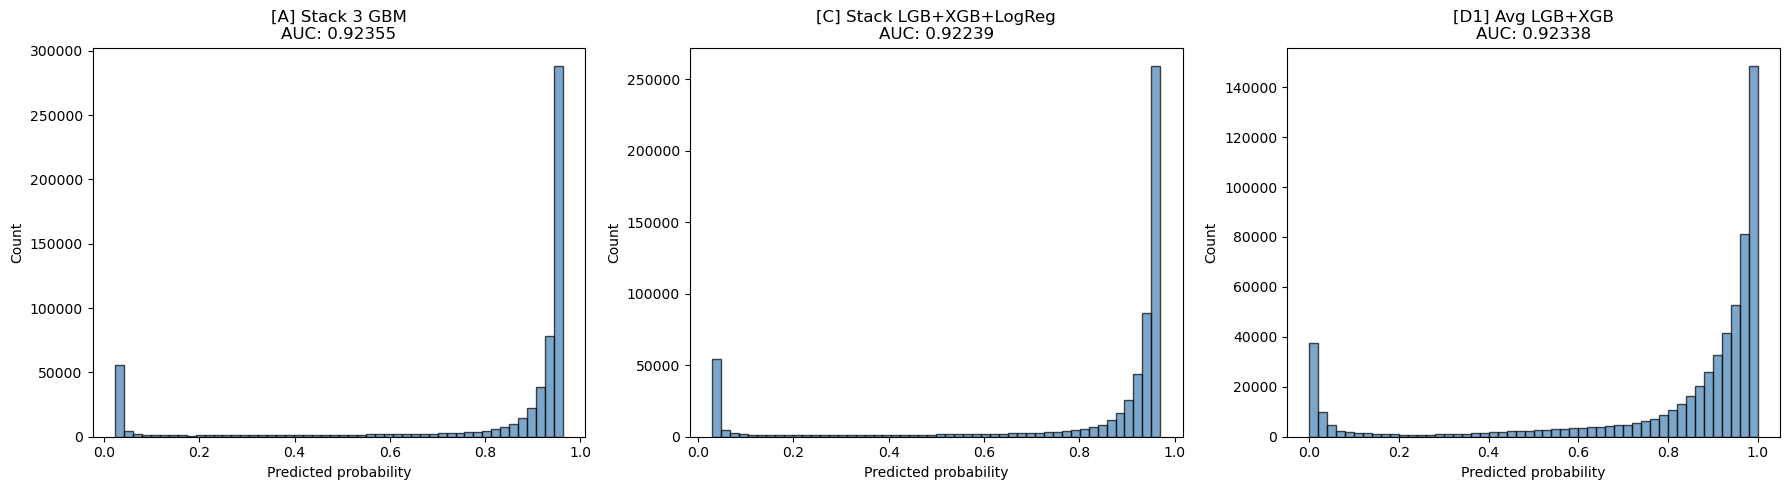

In [ ]:
variants = {
    '[A] Stack 3 GBM': stacking_3_preds,
    '[C] Stack LGB+XGB+LogReg': stacking_c_preds,
    '[D1] Avg LGB+XGB': avg_2_preds,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, preds) in zip(axes, variants.items()):
    auc = roc_auc_score(y, preds)
    ax.hist(preds, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{name}\nAUC: {auc:.5f}')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

Rozkłady wychodzą bardzo podobnie, czego się spodziewaliśmy po podobieństwie modeli.

Najlepszy wariant: A (AUC: 0.92355)

              precision    recall  f1-score   support

         0.0       0.86      0.64      0.73    119500
         1.0       0.91      0.97      0.94    474494

    accuracy                           0.91    593994
   macro avg       0.89      0.81      0.84    593994
weighted avg       0.90      0.91      0.90    593994



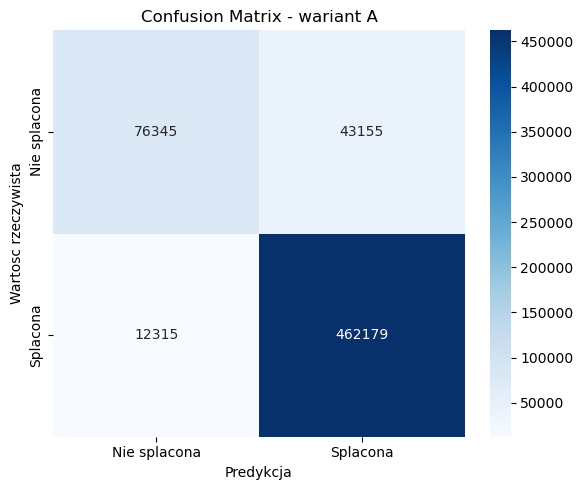

In [19]:
# Classification report i confusion matrix dla najlepszego wariantu
all_variants = {
    'A': (auc_3, stacking_3_preds),
    'B': (auc_5, stacking_5_preds),
    'C': (auc_c, stacking_c_preds),
    'D1': (auc_avg_2, avg_2_preds),
    'D2': (auc_avg_3, avg_3_preds),
    'D3': (auc_avg_5, avg_5_preds),
}
best_key = max(all_variants, key=lambda k: all_variants[k][0])
best_auc_val, best_preds = all_variants[best_key]

print(f"Najlepszy wariant: {best_key} (AUC: {best_auc_val:.5f})\n")

best_classes = (best_preds > 0.5).astype(int)
print(classification_report(y, best_classes))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, best_classes)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Nie splacona', 'Splacona'],
            yticklabels=['Nie splacona', 'Splacona'])
ax.set_xlabel('Predykcja')
ax.set_ylabel('Wartosc rzeczywista')
ax.set_title(f'Confusion Matrix - wariant {best_key}')
plt.tight_layout()
plt.show()

## Wybor finalnego modelu i submission

In [ ]:
test_meta_3 = pd.DataFrame({'LightGBM': test_lgb, 'XGBoost': test_xgb, 'CatBoost': test_cat})
test_meta_5 = pd.DataFrame({'LightGBM': test_lgb, 'XGBoost': test_xgb, 'CatBoost': test_cat, 'LogReg': test_logit, 'RF': test_rf})
test_meta_c = pd.DataFrame({'LightGBM': test_lgb, 'XGBoost': test_xgb, 'LogReg': test_logit})

test_variants = {
    'A': meta_model_3.predict_proba(test_meta_3)[:, 1],
    'B': meta_model_5.predict_proba(test_meta_5)[:, 1],
    'C': meta_model_c.predict_proba(test_meta_c)[:, 1],
    'D1': w_2[0]*test_lgb + w_2[1]*test_xgb,
    'D2': w_3[0]*test_lgb + w_3[1]*test_xgb + w_3[2]*test_logit,
    'D3': sum(w_i * p for w_i, p in zip(w_5, [test_lgb, test_xgb, test_cat, test_logit, test_rf])),
}

final_test_preds = test_variants[best_key]

print(f"Finalny wariant: {best_key} (OOF AUC: {best_auc_val:.5f})")

submission = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': final_test_preds
})

submission.to_csv('..//submissions/submission_final_29.03.csv', index=False)

print(f"\nWymiary submission: {submission.shape}")
print(f"\nStatystyki predykcji:")
print(f"  Srednia:  {final_test_preds.mean():.4f}")
print(f"  Mediana:  {np.median(final_test_preds):.4f}")
print(f"  Min:      {final_test_preds.min():.4f}")
print(f"  Max:      {final_test_preds.max():.4f}")
print(f"\nZapisano do ..//submissions/submission.csv")
submission.head(10)

Finalny wariant: A (OOF AUC: 0.92355)

Wymiary submission: (254569, 2)

Statystyki predykcji:
  Srednia:  0.7999
  Mediana:  0.9434
  Min:      0.0228
  Max:      0.9638

Zapisano do ..//submissions/submission.csv


,id,loan_paid_back
0,593994,0.945095
1,593995,0.958625
2,593996,0.527306
3,593997,0.934963
4,593998,0.956142
5,593999,0.957934
6,594000,0.960723
7,594001,0.955384
8,594002,0.944221
9,594003,0.023039
